In [2]:
import os
from typing import TypedDict

from dotenv import load_dotenv

from langchain_google_genai import ChatGoogleGenerativeAI

from langgraph.graph import StateGraph
from langgraph.graph import START, END

In [3]:
# ==================================================
# Load Environment Variables
# ==================================================

load_dotenv()

# ==================================================
# Load Gemini API Key
# ==================================================

os.environ["GOOGLE_API_KEY"] = os.getenv("GOOGLE_API_KEY")

In [5]:
# ==================================================
# Initialize LLM
# ==================================================


llm = ChatGoogleGenerativeAI(
    model="gemini-2.5-flash",
    temperature=0.3
)

In [4]:

class BlogState(TypedDict):

    title: str
    outline: str
    content: str

## Creating Nodes

In [6]:
def create_outline(state: BlogState) -> BlogState:

    # fetch title
    title = state['title']

    # call llm gen outline
    prompt = f'Generate a detailed outline for a blog on the topic - {title}'
    outline = llm.invoke(prompt).content

    # update state
    state['outline'] = outline

    return state

In [7]:

def create_blog(state: BlogState) -> BlogState:

    title = state['title']
    outline = state['outline']

    prompt = f'Write a detailed blog on the title - {title} using the follwing outline \n {outline}'

    content = llm.invoke(prompt).content

    state['content'] = content

    return state

## Define and Compile Graph

In [8]:
graph = StateGraph(BlogState)

# nodes
graph.add_node('create_outline', create_outline)
graph.add_node('create_blog', create_blog)

# edges
graph.add_edge(START, 'create_outline')
graph.add_edge('create_outline', 'create_blog')
graph.add_edge('create_blog', END)

workflow = graph.compile()

In [9]:
intial_state = {'title': 'Rise of AI in India'}

final_state = workflow.invoke(intial_state)

print(final_state)

{'title': 'Rise of AI in India', 'outline': 'Here\'s a detailed outline for a blog post on "The Rise of AI in India," designed to be comprehensive, engaging, and informative.\n\n---\n\n## Blog Title Options:\n*   India\'s AI Ascent: Unpacking the Revolution Shaping the Nation\n*   The AI Awakening: How India is Becoming a Global Powerhouse\n*   From Code to Consciousness: The Rapid Rise of AI in India\n*   Beyond the Hype: Understanding India\'s AI Transformation\n\n---\n\n## I. Introduction (Approx. 150-200 words)\n\n*   **A. Catchy Hook:** Start with a compelling statement about AI\'s global impact and its specific resonance in a developing nation like India. (e.g., "While the world grapples with the implications of Artificial Intelligence, India isn\'t just watching from the sidelines; it\'s actively shaping its future with AI at its core.")\n*   **B. Brief Definition of AI:** A concise explanation of what AI encompasses (machine learning, deep learning, NLP, computer vision, etc.) 

In [10]:
print(final_state['outline'])

Here's a detailed outline for a blog post on "The Rise of AI in India," designed to be comprehensive, engaging, and informative.

---

## Blog Title Options:
*   India's AI Ascent: Unpacking the Revolution Shaping the Nation
*   The AI Awakening: How India is Becoming a Global Powerhouse
*   From Code to Consciousness: The Rapid Rise of AI in India
*   Beyond the Hype: Understanding India's AI Transformation

---

## I. Introduction (Approx. 150-200 words)

*   **A. Catchy Hook:** Start with a compelling statement about AI's global impact and its specific resonance in a developing nation like India. (e.g., "While the world grapples with the implications of Artificial Intelligence, India isn't just watching from the sidelines; it's actively shaping its future with AI at its core.")
*   **B. Brief Definition of AI:** A concise explanation of what AI encompasses (machine learning, deep learning, NLP, computer vision, etc.) and its transformative potential.
*   **C. Thesis Statement:** Ind

In [11]:

print(final_state['content'])

## India's AI Ascent: Unpacking the Revolution Shaping the Nation

While the world grapples with the profound implications of Artificial Intelligence, India isn't just watching from the sidelines; it's actively shaping its future with AI at its core. From bustling metropolises to remote villages, the transformative power of AI is beginning to redefine industries, improve lives, and unlock unprecedented opportunities across the subcontinent. At its heart, AI encompasses a range of technologies – machine learning, deep learning, natural language processing, and computer vision – designed to enable machines to perceive, reason, learn, and act like humans. This transformative potential is precisely why India is rapidly emerging as a significant player in the global AI landscape, driven by unique demographic, economic, and governmental factors, poised to leverage AI for both economic growth and social good. This blog post will delve into the powerful drivers behind India's AI boom, explore 

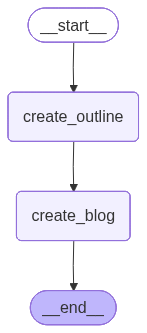

In [12]:
from IPython.display import Image
Image(workflow.get_graph().draw_mermaid_png())